In [18]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
from sklearn.datasets import fetch_california_housing

In [20]:
CHdf = fetch_california_housing()

In [21]:
CHdf.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [22]:
CHdf.target_names

['MedHouseVal']

In [23]:
CHdf.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [24]:
print(CHdf.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [25]:
CHdf.data.shape

(20640, 8)

In [26]:
df = pd.DataFrame(data=CHdf.data, columns=CHdf.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [27]:
CHdf.target_names

['MedHouseVal']

In [28]:
df['MedHouseVal'] = CHdf.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [30]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [31]:
df.corr()['MedHouseVal'].sort_values(ascending=False) # we can see in output that the most correlated feature with the target variable is 'MedInc'.

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [32]:
# sns.pairplot(data=df, hue='MedHouseVal')

In [33]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [34]:
cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup'] # from graph saw that these features have some outliers, so we will remove them using IQR method.

bounds = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    print(f"{col} - Q1: {Q1}, Q3: {Q3}")
    IQR = Q3 - Q1
    print(f"{col} - IQR: {IQR}")
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    bounds[col] = (lower, upper)
    print(f"{col} - Lower Bound: {lower}, Upper Bound: {upper}\n")  


AveRooms - Q1: 4.440716235896959, Q3: 6.052380952380952
AveRooms - IQR: 1.6116647164839932
AveRooms - Lower Bound: 2.023219161170969, Upper Bound: 8.469878027106942

AveBedrms - Q1: 1.006079046038478, Q3: 1.099526066350711
AveBedrms - IQR: 0.09344702031223284
AveBedrms - Lower Bound: 0.8659085155701288, Upper Bound: 1.2396965968190603

Population - Q1: 787.0, Q3: 1725.0
Population - IQR: 938.0
Population - Lower Bound: -620.0, Upper Bound: 3132.0

AveOccup - Q1: 2.4297411475535755, Q3: 3.2822609242736216
AveOccup - IQR: 0.8525197767200461
AveOccup - Lower Bound: 1.1509614824735064, Upper Bound: 4.5610405893536905



In [35]:
df1 = df.copy()

for col in cols:
    lower, upper = bounds[col]
    df1[col] = df1[col].clip(lower, upper)

df1[['Population', 'AveOccup']] = np.log1p(df1[['Population', 'AveOccup']])

In [36]:
df1.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,5.777652,1.268511,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,7.784057,1.134572,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,6.208590,1.335596,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,6.326149,1.266369,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,6.338594,1.157342,37.85,-122.25,3.422


In [38]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [37]:
df1.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.311003
HouseAge       0.105623
Population    -0.021366
Longitude     -0.045967
AveBedrms     -0.096055
Latitude      -0.144160
AveOccup      -0.280908
Name: MedHouseVal, dtype: float64

In [39]:
df2 = df1.copy()
df2['RoomsPerHousehold'] = df2['AveRooms'] / df2['AveOccup'] # higher is better coz more rooms per household means better living conditions.
df2['BedroomsPerRoom'] = df2['AveBedrms'] / df2['AveRooms'] # lower is better coz less bedrooms per room means more rooms per bedroom which means better living conditions.

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

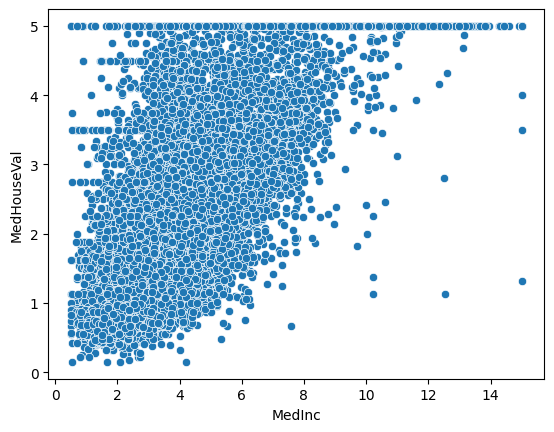

In [42]:
sns.scatterplot(data=df2, x='MedInc', y='MedHouseVal')

In [ ]:
df2.corr()['MedHouseVal'].sort_values(ascending=False) 

MedHouseVal          1.000000
MedInc               0.688075
RoomsPerHousehold    0.403278
AveRooms             0.311003
HouseAge             0.105623
Population          -0.021366
Longitude           -0.045967
AveBedrms           -0.096055
Latitude            -0.144160
BedroomsPerRoom     -0.244311
AveOccup            -0.280908
Name: MedHouseVal, dtype: float64

When using .corr() : 
> 0.5 or < -0.5 usually indicates good features 
0.2 or 0.5 are ok 
and anything other than are weak.

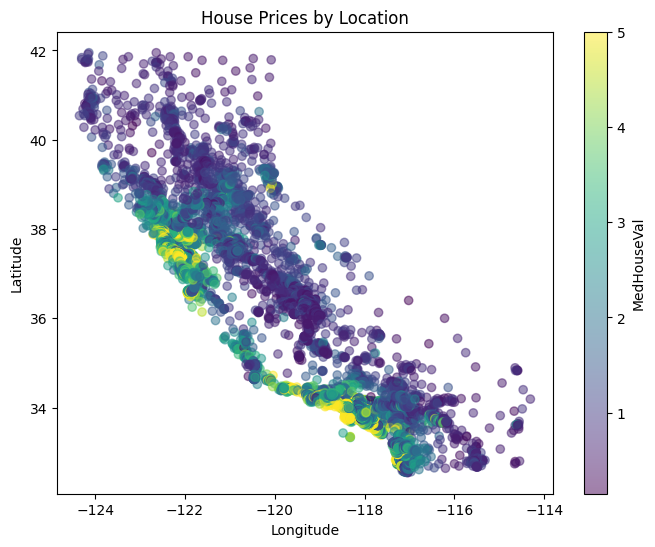

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    df2['Longitude'], 
    df2['Latitude'], 
    c=df2['MedHouseVal'], 
    cmap='viridis', 
    alpha=0.5
)
plt.colorbar(label='MedHouseVal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Prices by Location')
plt.show()

In [101]:
df2['Latitude'].unique()

array([37.88, 37.86, 37.85, 37.84, 37.83, 37.82, 37.81, 37.8 , 37.79,
       37.77, 37.78, 37.76, 37.75, 37.74, 37.73, 37.9 , 37.89, 37.87,
       37.72, 37.71, 37.7 , 37.69, 37.68, 37.64, 37.63, 37.66, 37.65,
       37.67, 37.61, 37.62, 37.6 , 37.59, 37.58, 37.57, 37.49, 37.52,
       37.56, 37.55, 37.54, 37.53, 37.51, 37.48, 37.47, 37.5 , 38.69,
       38.72, 38.52, 38.48, 38.45, 38.46, 38.43, 38.55, 38.54, 38.51,
       38.5 , 38.47, 38.44, 38.42, 38.37, 38.34, 38.32, 38.26, 38.38,
       38.4 , 38.39, 38.36, 38.31, 39.76, 39.78, 39.77, 39.74, 39.75,
       39.73, 39.71, 39.72, 39.7 , 39.82, 39.79, 39.68, 39.64, 39.66,
       39.59, 39.88, 40.06, 39.97, 39.86, 39.83, 39.8 , 39.69, 39.61,
       39.65, 39.55, 39.52, 39.53, 39.6 , 39.54, 39.5 , 39.49, 39.51,
       39.48, 39.47, 39.45, 39.44, 39.43, 39.4 , 39.39, 39.33, 39.37,
       39.35, 39.34, 39.32, 39.36, 39.38, 39.42, 39.41, 38.15, 38.12,
       38.09, 38.07, 37.97, 38.24, 38.2 , 38.16, 38.11, 38.28, 38.19,
       38.25, 38.41,

In [68]:
df3 = df2.copy()
df3['Lat_round'] = df3['Latitude'].round(0)
df3['Long_round'] = df3['Longitude'].round(0)
df3['MedHouseVal_round'] = df3['MedHouseVal'].round(0)

High_Value_regions = df3[df3['MedHouseVal_round'] > 4.5][['Lat_round', 'Long_round', 'MedHouseVal_round']].drop_duplicates()

High_Value_regions

,Lat_round,Long_round,MedHouseVal_round
0,38.0,-122.0,5.0
923,37.0,-122.0,5.0
1914,39.0,-120.0,5.0
3480,34.0,-119.0,5.0
3746,34.0,-118.0,5.0
9310,38.0,-123.0,5.0
9796,36.0,-122.0,5.0
10418,33.0,-118.0,5.0
12138,34.0,-117.0,5.0
12211,33.0,-117.0,5.0


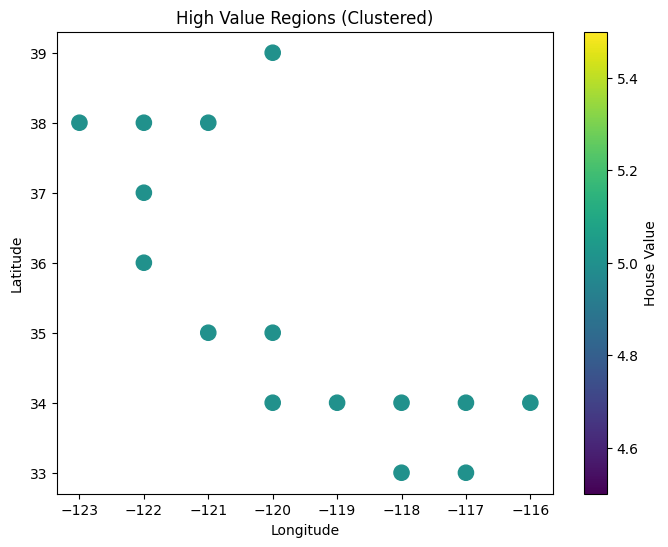

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    High_Value_regions['Long_round'],
    High_Value_regions['Lat_round'],
    c=High_Value_regions['MedHouseVal_round'],
    cmap='viridis',
    s=120
)

plt.colorbar(label='House Value')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High Value Regions (Clustered)')

plt.show()

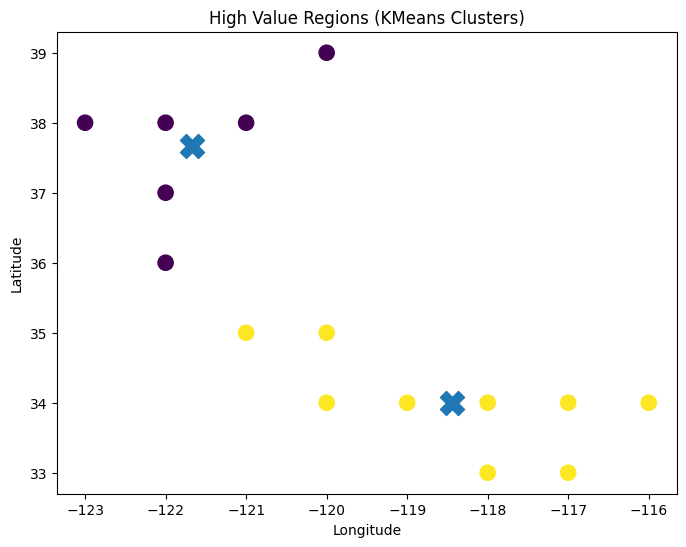

High Value regions main Coordinates are: [  37.66666667 -121.66666667], [  34.         -118.44444444]


In [ ]:
from sklearn.cluster import KMeans

X = High_Value_regions[['Lat_round', 'Long_round']]

kmeans = KMeans(n_clusters=2, random_state=42)
High_Value_regions['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

plt.scatter(
    High_Value_regions['Long_round'],
    High_Value_regions['Lat_round'],
    c=High_Value_regions['Cluster'],
    s=120
)

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:,1], centers[:,0],
    s=300, marker='X'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High Value Regions (KMeans Clusters)')

plt.show()
print(f"High Value regions main Coordinates are: {centers[0]}, {centers[1]}")

Took two coordinates from where the medhouseval where high

In [91]:
HVR1 = (37.77, -122.42)
HVR2 = (34.05, -118.24)

df3['Distance_From_HVR1'] = np.sqrt((df3['Latitude'] - HVR1[0])**2 + (df3['Longitude'] - HVR1[1])**2)
df3['Distance_From_HVR2'] = np.sqrt((df3['Latitude'] - HVR2[0])**2 + (df3['Longitude'] - HVR2[1])**2)
df3.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,Lat_round,Long_round,MedHouseVal_round,Distance_From_HVR1,Distance_From_HVR2,Distance_to_Nearest_Hub
0,8.3252,41.0,6.984127,1.023810,5.777652,1.268511,37.88,-122.23,4.526,5.505766,0.146591,38.0,-122.0,5.0,0.219545,5.530732,0.219545
1,8.3014,21.0,6.238137,0.971880,7.784057,1.134572,37.86,-122.22,3.585,5.498230,0.155797,38.0,-122.0,4.0,0.219317,5.509673,0.219317
2,7.2574,52.0,8.288136,1.073446,6.208590,1.335596,37.85,-122.24,3.521,6.205573,0.129516,38.0,-122.0,4.0,0.196977,5.517246,0.196977
3,5.6431,52.0,5.817352,1.073059,6.326149,1.266369,37.85,-122.25,3.413,4.593727,0.184458,38.0,-122.0,3.0,0.187883,5.524500,0.187883
4,3.8462,52.0,6.281853,1.081081,6.338594,1.157342,37.85,-122.25,3.422,5.427826,0.172096,38.0,-122.0,3.0,0.187883,5.524500,0.187883


In [82]:
df3.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal           1.000000
MedHouseVal_round     0.969862
MedInc                0.688075
RoomsPerHousehold     0.403278
AveRooms              0.311003
HouseAge              0.105623
Population           -0.021366
Long_round           -0.036663
Distance_From_HVR1   -0.041247
Longitude            -0.045967
AveBedrms            -0.096055
Distance_From_HVR2   -0.116654
Latitude             -0.144160
Lat_round            -0.150541
BedroomsPerRoom      -0.244311
AveOccup             -0.280908
Name: MedHouseVal, dtype: float64

In [86]:
df3['Distance_to_Nearest_Hub'] = np.minimum(df3['Distance_From_HVR1'], df3['Distance_From_HVR2'])
df3.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,Lat_round,Long_round,MedHouseVal_round,Distance_From_HVR1,Distance_From_HVR2,Distance_to_Nearest_Hub
0,8.3252,41.0,6.984127,1.023810,5.777652,1.268511,37.88,-122.23,4.526,5.505766,0.146591,38.0,-122.0,5.0,0.219545,5.530732,0.219545
1,8.3014,21.0,6.238137,0.971880,7.784057,1.134572,37.86,-122.22,3.585,5.498230,0.155797,38.0,-122.0,4.0,0.219317,5.509673,0.219317
2,7.2574,52.0,8.288136,1.073446,6.208590,1.335596,37.85,-122.24,3.521,6.205573,0.129516,38.0,-122.0,4.0,0.196977,5.517246,0.196977
3,5.6431,52.0,5.817352,1.073059,6.326149,1.266369,37.85,-122.25,3.413,4.593727,0.184458,38.0,-122.0,3.0,0.187883,5.524500,0.187883
4,3.8462,52.0,6.281853,1.081081,6.338594,1.157342,37.85,-122.25,3.422,5.427826,0.172096,38.0,-122.0,3.0,0.187883,5.524500,0.187883


In [88]:
df3.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal                1.000000
MedHouseVal_round          0.969862
MedInc                     0.688075
RoomsPerHousehold          0.403278
AveRooms                   0.311003
HouseAge                   0.105623
Population                -0.021366
Long_round                -0.036663
Distance_From_HVR1        -0.041247
Longitude                 -0.045967
AveBedrms                 -0.096055
Distance_From_HVR2        -0.116654
Latitude                  -0.144160
Lat_round                 -0.150541
BedroomsPerRoom           -0.244311
AveOccup                  -0.280908
Distance_to_Nearest_Hub   -0.438500
Name: MedHouseVal, dtype: float64

In [ ]:
df3 = df3.drop(columns=['MedHouseVal_round'], axis=1)

In [95]:
df3.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,Lat_round,Long_round,Distance_From_HVR1,Distance_From_HVR2,Distance_to_Nearest_Hub
0,8.3252,41.0,6.984127,1.023810,5.777652,1.268511,37.88,-122.23,4.526,5.505766,0.146591,38.0,-122.0,0.219545,5.530732,0.219545
1,8.3014,21.0,6.238137,0.971880,7.784057,1.134572,37.86,-122.22,3.585,5.498230,0.155797,38.0,-122.0,0.219317,5.509673,0.219317
2,7.2574,52.0,8.288136,1.073446,6.208590,1.335596,37.85,-122.24,3.521,6.205573,0.129516,38.0,-122.0,0.196977,5.517246,0.196977
3,5.6431,52.0,5.817352,1.073059,6.326149,1.266369,37.85,-122.25,3.413,4.593727,0.184458,38.0,-122.0,0.187883,5.524500,0.187883
4,3.8462,52.0,6.281853,1.081081,6.338594,1.157342,37.85,-122.25,3.422,5.427826,0.172096,38.0,-122.0,0.187883,5.524500,0.187883


In [ ]:
df3['IncPerOcc'] = df3['MedInc'] / df3['AveOccup'] # this feature is created to capture the income per occupant, which can be a strong indicator of the economic status of the household and its ability to afford housing.

df3.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal                1.000000
IncPerOcc                  0.740941
MedInc                     0.688075
RoomsPerHousehold          0.403278
AveRooms                   0.311003
HouseAge                   0.105623
Population                -0.021366
Long_round                -0.036663
Distance_From_HVR1        -0.041247
Longitude                 -0.045967
AveBedrms                 -0.096055
Distance_From_HVR2        -0.116654
Latitude                  -0.144160
Lat_round                 -0.150541
BedroomsPerRoom           -0.244311
AveOccup                  -0.280908
Distance_to_Nearest_Hub   -0.438500
Name: MedHouseVal, dtype: float64

<Axes: xlabel='IncPerOcc', ylabel='MedHouseVal'>

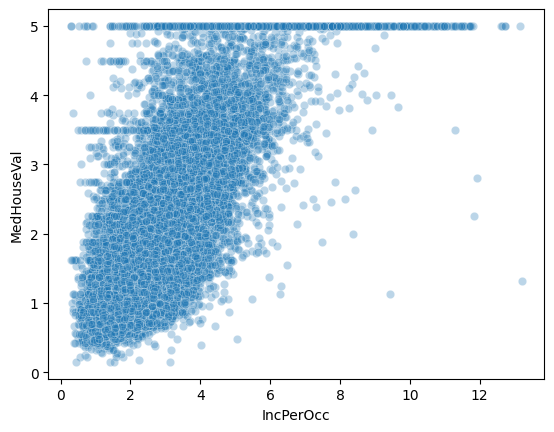

In [97]:
sns.scatterplot(x='IncPerOcc', y='MedHouseVal', data=df3, alpha=0.3)

In [98]:
df3['Lat_round'].unique()

array([38., 37., 39., 40., 42., 36., 41., 33., 35., 34.])

In [99]:
df3['Long_round'].unique()

array([-122., -120., -121., -123., -124., -119., -116., -115., -118.,
       -117., -114.])

In [ ]:
# Combine rounded coords into a single feature
df3['Location_Grp'] = df3['Lat_round'].astype(str) + ',' + df3['Long_round'].astype(str)
df3['Location_Grp'].unique()

array(['38.0,-122.0', '37.0,-122.0', '39.0,-120.0', '38.0,-121.0',
       '39.0,-121.0', '40.0,-122.0', '40.0,-121.0', '39.0,-122.0',
       '38.0,-120.0', '39.0,-123.0', '42.0,-124.0', '37.0,-120.0',
       '37.0,-119.0', '36.0,-120.0', '37.0,-121.0', '40.0,-123.0',
       '41.0,-124.0', '40.0,-124.0', '33.0,-116.0', '33.0,-115.0',
       '37.0,-118.0', '36.0,-118.0', '36.0,-117.0', '36.0,-116.0',
       '35.0,-119.0', '35.0,-120.0', '36.0,-119.0', '35.0,-118.0',
       '41.0,-121.0', '41.0,-120.0', '40.0,-120.0', '34.0,-118.0',
       '34.0,-119.0', '33.0,-118.0', '38.0,-123.0', '39.0,-124.0',
       '42.0,-121.0', '42.0,-120.0', '39.0,-119.0', '38.0,-119.0',
       '38.0,-118.0', '36.0,-121.0', '36.0,-122.0', '34.0,-117.0',
       '33.0,-117.0', '34.0,-116.0', '34.0,-115.0', '34.0,-114.0',
       '35.0,-117.0', '35.0,-116.0', '35.0,-115.0', '35.0,-121.0',
       '34.0,-120.0', '41.0,-122.0', '41.0,-123.0', '42.0,-122.0',
       '42.0,-123.0'], dtype=object)

In [ ]:
# Thought the whole number would be a little inaccurate so rounded it to .1 instead of 0, so that we can capture more localized clusters.
df3['Block_ID'] = df3['Latitude'].round(1).astype(str) + '_' + df3['Longitude'].round(1).astype(str)
df3['Block_ID'].value_counts()

Block_ID
34.0_-118.3    422
34.0_-118.2    360
34.0_-118.4    348
37.8_-122.2    291
34.2_-118.4    289
              ... 
38.9_-121.9      1
38.8_-122.2      1
38.9_-122.2      1
38.5_-120.9      1
34.5_-119.1      1
Name: count, Length: 1563, dtype: int64

In [ ]:
sns.histplot(df2['MedHouseVal'], bins=50)
plt.title("Distribution of House Values ")
plt.show()
# there is a spike at 5.0 which is the max value of the target variable, which means there are many capped values in the dataset. This means that a houseworth $500k, but in reality, it could be $600k or $2M—the data just stopped counting. Taking in this values will give wrong pattern to the model, so we will remove them.

In [225]:
# Removing the capped rows 
df3 = df3[df3['MedHouseVal'] < 4.9]
print(f"Removed {len(df2) - len(df3)} capped rows.")

Removed 1032 capped rows.


df4 running seperate testing on it, using block mean val

In [228]:
# Creating df4 for only correlation analysis of the new feature with the target variable. Will not use in model cause it will cause data leakage.
df4 = df3.copy()
df4.columns 

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold',
       'BedroomsPerRoom', 'Lat_round', 'Long_round', 'Distance_From_HVR1',
       'Distance_From_HVR2', 'Distance_to_Nearest_Hub', 'IncPerOcc',
       'Block_ID', 'Wealth_Location_Score'],
      dtype='object')

In [229]:
df4 = df4.drop ([
    'Distance_From_HVR1',
    'Distance_From_HVR2',
    'Lat_round', 'Long_round',], axis =1)
df4.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold',
       'BedroomsPerRoom', 'Distance_to_Nearest_Hub', 'IncPerOcc', 'Block_ID',
       'Wealth_Location_Score'],
      dtype='object')

In [184]:
df4.shape

(19608, 15)

In [231]:
from sklearn.model_selection import train_test_split

X4 = df4.drop('MedHouseVal', axis=1)
y4 = df4['MedHouseVal']
    
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)
train_data = X4_train.copy()
train_data['MedHouseVal'] = y4_train

block_mean = train_data.groupby('Block_ID')['MedHouseVal'].mean()
X4_train['Block_Value'] = X4_train['Block_ID'].map(block_mean)
X4_test['Block_Value'] = X4_test['Block_ID'].map(block_mean)

global_mean = y4_train.mean()
X4_test['Block_Value'] = X4_test['Block_Value'].fillna(global_mean)

X4_train = X4_train.drop('Block_ID', axis=1)
X4_test = X4_test.drop('Block_ID', axis=1)

X4_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom',
       'Distance_to_Nearest_Hub', 'IncPerOcc', 'Wealth_Location_Score',
       'Block_Value'],
      dtype='object')

In [245]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

xgb_model4 = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model4.fit(X4_train, y4_train)
y4_pred_xg = xgb_model4.predict(X4_test)

print(f"Root Mean Squared Error: ${mean_squared_error(y4_test, y4_pred_xg) * 100000:.2f}") # Converting back to USD
print(f"R-Squared Score: {r2_score(y4_test, y4_pred_xg):.4f}")

Root Mean Squared Error: $17856.31
R-Squared Score: 0.8148


In [170]:
# We add +1 to the denominator to avoid division by zero
df3['Wealth_Location_Score'] = df3['MedInc'] / (df3['Distance_to_Nearest_Hub'] + 1)
df3['Wealth_Location_Score'] = df3['MedInc'] / (df3['Distance_to_Nearest_Hub'] + 1)

C:\Users\aaish\AppData\Local\Temp\ipykernel_22940\1527306242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Wealth_Location_Score'] = df3['MedInc'] / (df3['Distance_to_Nearest_Hub'] + 1)
C:\Users\aaish\AppData\Local\Temp\ipykernel_22940\1527306242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Wealth_Location_Score'] = df3['MedInc'] / (df3['Distance_to_Nearest_Hub'] + 1)


In [171]:
df3.columns    

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold',
       'BedroomsPerRoom', 'Lat_round', 'Long_round', 'Distance_From_HVR1',
       'Distance_From_HVR2', 'Distance_to_Nearest_Hub', 'IncPerOcc',
       'Block_ID', 'Wealth_Location_Score'],
      dtype='object')

In [172]:
df5 = df3.copy()    
df5.drop(columns=['MedHouseVal', 'Lat_round', 'Long_round', 'Block_ID', 'Distance_From_HVR1', 'Distance_From_HVR2'], axis=1, inplace=True)
df5.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom',
       'Distance_to_Nearest_Hub', 'IncPerOcc', 'Wealth_Location_Score'],
      dtype='object')

In [ ]:
#df6 has lesser cols to reduce multicollinearity and to capture only the most important features based on correlation analysis and domain knowledge. 
df6 = df5.copy()
df6.drop(columns=['AveRooms',
    'AveBedrms',
    'Latitude',
    'Longitude',
    'MedInc',
    'AveOccup',], axis=1, inplace=True)
df6.columns

Index(['HouseAge', 'Population', 'RoomsPerHousehold', 'BedroomsPerRoom',
       'Distance_to_Nearest_Hub', 'IncPerOcc'],
      dtype='object')

In [173]:
X = df5
y = df3['MedHouseVal']

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total b4 split: {X.shape}")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Total b4 split: (19608, 13)
Training set size: (15686, 13)
Testing set size: (3922, 13)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_split=5,  max_depth=25, n_jobs=-1, random_state=42)

# rf_model.fit(X_train, y_train)
# y_pred = rf_model.predict(X_test)

rf_model.fit(X_train, np.log1p(y_train))
y_log_pred = rf_model.predict(X_test)
y_pred = np.expm1(y_log_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: ${rmse * 100000:.2f}") # Converting back to USD
print(f"R-Squared Score: {r2:.4f}")

Root Mean Squared Error: $47441.08
R-Squared Score: 0.7666


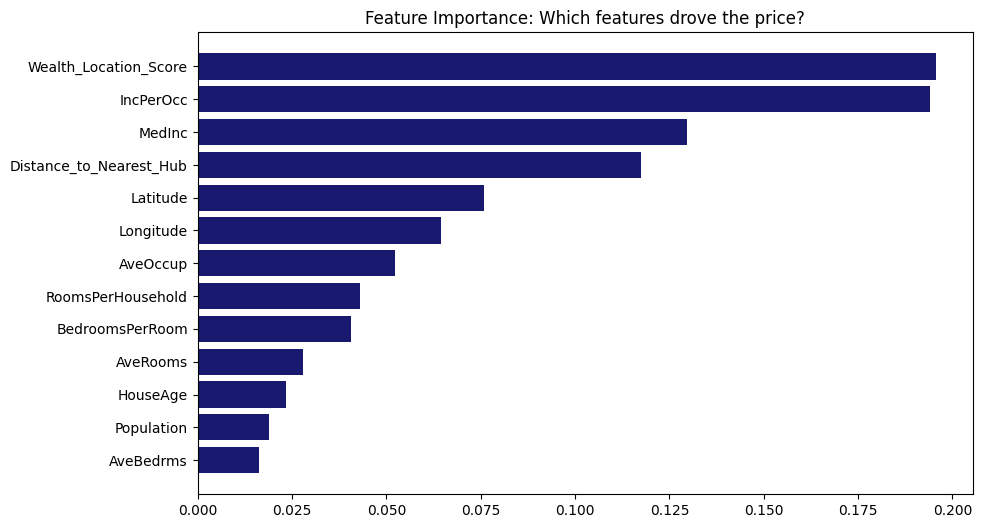

In [176]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='midnightblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance: Which features drove the price?')
plt.show()

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=1500, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=10, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xg = xgb_model.predict(X_test)

print(f"Root Mean Squared Error: ${mean_squared_error(y_test, y_pred_xg) * 100000:.2f}") # Converting back to USD
print(f"R-Squared Score: {r2_score(y_test, y_pred_xg):.4f}")

Root Mean Squared Error: $17428.50
R-Squared Score: 0.8193


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')

print(f"All CV Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}") 

# If Standard Deviation (the cv_scores.std()) is lower than 0.02, indicates that the model's performance is consistent across different subsets of the data, which is a good sign of its generalizability.

All CV Scores: [0.81935036 0.83512371 0.82685735 0.8270962  0.82823824]
Mean R2 Score: 0.8273
Standard Deviation: 0.0050


In [224]:
# 1. Define the features to exclude
low_importance_features = ['Population', 'AveBedrms'] # these features have very low importance score in the feature importance plot, so we will remove them to see if it improves the model performance.

# 2. Update your X_train and X_test
X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

# 3. Re-run your final tuned model with the reduced features
xgb_model_reduced = XGBRegressor(
    subsample=0.9, n_estimators=1500, max_depth=6, learning_rate=0.03, colsample_bytree=0.7, random_state=42
)

# 4. Check the new CV score
from sklearn.model_selection import cross_val_score
new_cv_scores = cross_val_score(xgb_model_reduced, X_train_reduced, y_train, cv=kf, scoring='r2')

print(f"New Mean R2 Score: {new_cv_scores.mean():.4f}")
print(f"Improvement: {new_cv_scores.mean() - 0.8338:.4f}")


New Mean R2 Score: 0.8293
Improvement: -0.0045


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [ 500, 1000, 1500],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# n_iter=10 will try 10 random combinations using 5-fold CV
rs_xgb = RandomizedSearchCV(xgb_model, param_grid, n_iter=10, cv=kf, scoring='r2', n_jobs=-1, verbose=1)
rs_xgb.fit(X, y)

print(f"Best Score: {rs_xgb.best_score_}")
print(f"Best Params: {rs_xgb.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Score: 0.8338184021940254
Best Params: {'subsample': 0.9, 'n_estimators': 1500, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


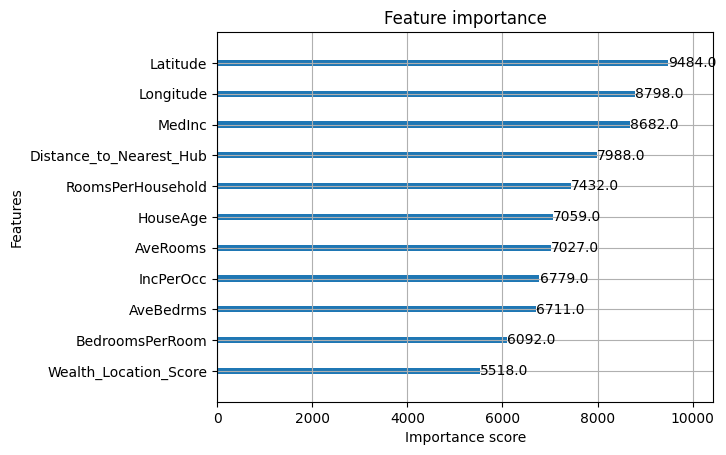

In [ ]:
from xgboost import plot_importance
plot_importance(xgb_model)
plt.show()

In [249]:
# The "Champion" Model
final_model = XGBRegressor(
     n_estimators=1500, max_depth=6, learning_rate=0.03, subsample=0.9, colsample_bytree=0.7,
    random_state=42
)

final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Final Test Score 
final_test_preds = final_model.predict(X_test)
print(f"Final R2 Score: {r2_score(y_test, final_test_preds):.4f}")

Final R2 Score: 0.8276


In [287]:
# Checking residuals to see if there is any pattern left in the errors that the model is making, which can indicate if there are still some relationships in the data that the model hasn't captured yet. Ideally, we want to see a random scatter of points around the horizontal line at zero, which would suggest that the model's errors are random and not systematically biased. If we see patterns (like a funnel shape or a curve), it could indicate heteroscedasticity or non-linearity that the model hasn't captured, suggesting room for improvement.

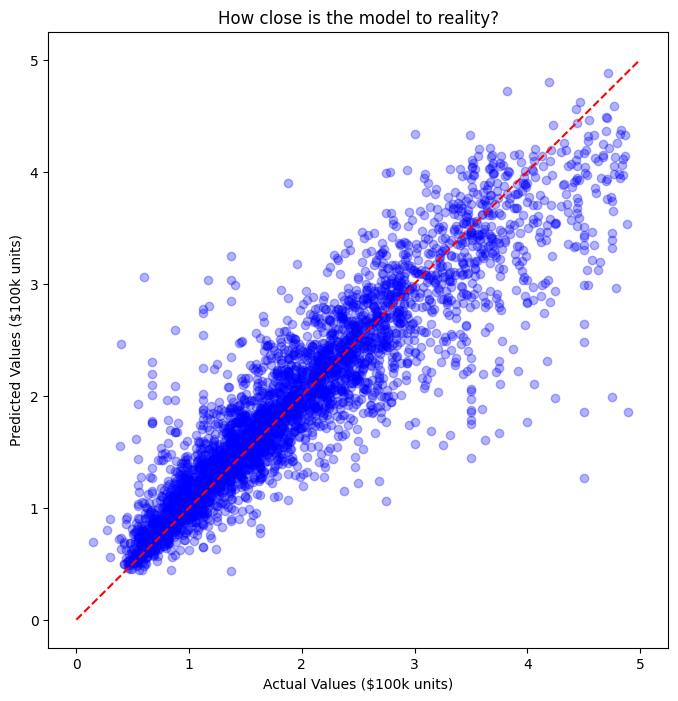

In [ ]:
y_test_preds = final_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_preds, alpha=0.3, color='blue')
plt.plot([0, 5], [0, 5], color='red', linestyle='--') # The "Perfect" line
plt.xlabel('Actual Values ($100k units)')
plt.ylabel('Predicted Values ($100k units)')
plt.title('How close is the model to reality?')
plt.show()

#Dots on the Red Line: Correct predictions
#Dots below the Red Line: under - predicted
#Dots above the Red Line: over-predicting

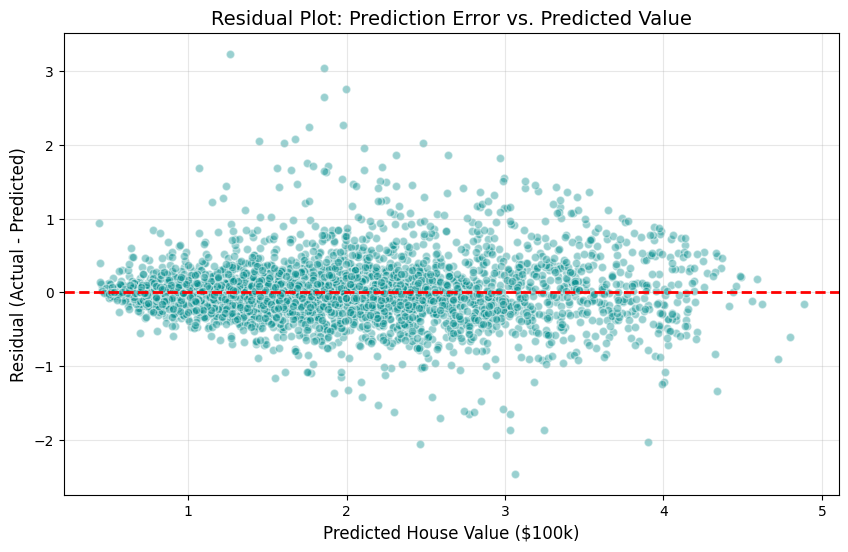

In [ ]:
residuals = y_test - final_test_preds

plt.figure(figsize=(10, 6))
plt.scatter(final_test_preds, residuals, alpha=0.4, color='darkcyan', edgecolors='white')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Residual Plot: Prediction Error vs. Predicted Value', fontsize=14)
plt.xlabel('Predicted House Value ($100k)', fontsize=12)
plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

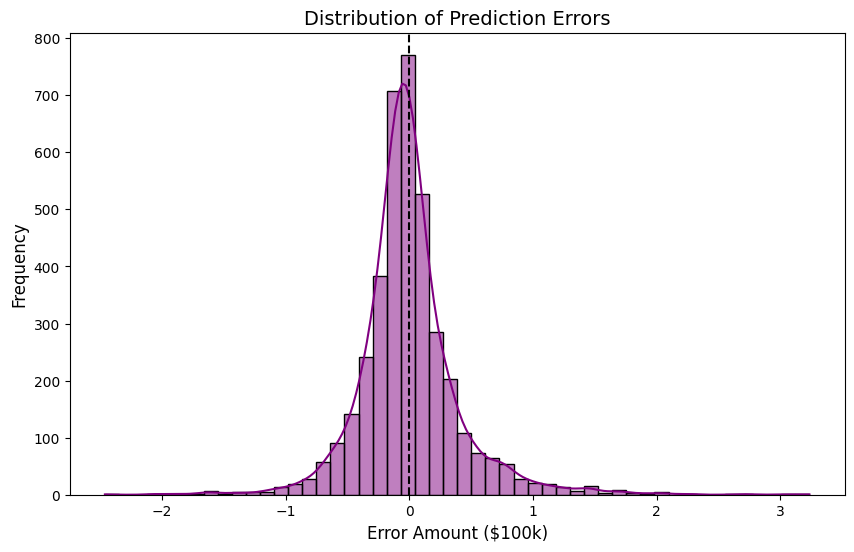

In [286]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Error Amount ($100k)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [256]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom',
       'Distance_to_Nearest_Hub', 'IncPerOcc', 'Wealth_Location_Score'],
      dtype='object')

In [257]:
# Handling New Data for Prediction

def prepare_for_prediction(new_data, train_columns):

    """
    new_data: dict or list of dicts with raw California features
    train_columns: the list of columns the model was trained on
    """


    input_df = pd.DataFrame(new_data)
    
    # Feature engineering for the new data 
    input_df['IncPerOcc'] = input_df['MedInc'] / input_df['AveOccup']

    input_df['RoomsPerHousehold'] = input_df['AveRooms'] / input_df['AveOccup']
    
    input_df['BedroomsPerRoom'] = input_df['AveBedrms'] / input_df['AveRooms']
    
    hub_lat, hub_lon = 37.7749, -122.4194
    input_df['Distance_to_Nearest_Hub'] = np.sqrt(
        (input_df['Latitude'] - hub_lat)**2 + (input_df['Longitude'] - hub_lon)**2
    )
    
    input_df['Wealth_Location_Score'] = input_df['MedInc'] / (input_df['Distance_to_Nearest_Hub'] + 1)
    

    # This ensures the new data has the same column order as the training set
    # and ignores columns dropped (like Population or AveOccup)
    input_df = input_df[train_columns]
    
    return input_df

In [284]:
# Testing model with new values

In [ ]:
testval2 = pd.DataFrame([CHdf.data[0]], columns=CHdf.feature_names)

Xnew2 = prepare_for_prediction(testval2, X_train.columns.tolist())
Xnew2_prediction = final_model.predict(Xnew2)

print(f"Predicted House Value for the new data point: ${Xnew2_prediction [0] * 100000:.2f}") # in US dollars
print(f"Actual House Value for the new data point: ${CHdf.target[0] * 100000:.2f}") # in US dollars


Predicted House Value for the new data point: $315018.41
Actual House Value for the new data point: $452600.00


In [ ]:
test_val = [{
    'MedInc': 8.32, 
    'HouseAge': 41.0, 
    'AveRooms': 6.98, 
    'AveBedrms': 1.02, 
    'Population': 322.0, 
    'AveOccup': 2.55, 
    'Latitude': 37.88, 
    'Longitude': -122.23
}]

X_new = prepare_for_prediction(test_val, X_train.columns.tolist())

Xnew_prediction = final_model.predict(X_new)
print(f"Predicted House Value: ${Xnew_prediction[0] * 100000:.2f}") # in US dollars 

Predicted House Value: $315577.56


In [ ]:
#Finally pickling the model and features for deployment

In [289]:
import joblib

joblib.dump(final_model, 'housing_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

['model_features.pkl']